In [1]:
from numpy import * 
from matplotlib.pyplot import *


In [2]:
import os
import glob
import numpy as np

def read_tpetra_output(label, nx, ny, directory='.'):
    """
    Reads multiple Tpetra vector output files of the form 'label_<rank>.out'
    and returns a 2D NumPy array of shape (nx, ny).

    Parameters:
        label (str): The prefix label used in the file names (e.g., "rhs").
        nx (int): Number of grid points in x-direction.
        ny (int): Number of grid points in y-direction.
        directory (str): Directory where the files are located (default: current).

    Returns:
        np.ndarray: Assembled 2D array of shape (nx, ny).
    """
    data = np.zeros((nx, ny))

    # Find all matching files
    pattern = os.path.join(directory, f"{label}.out")
    files = glob.glob(pattern)

    if not files:
        raise FileNotFoundError(f"No files found with pattern: {pattern}")

    for filename in files:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip().strip('()')
                if not line:
                    continue
                i_str, j_str, val_str = line.split(',')
                i = int(i_str.strip())
                j = int(j_str.strip())
                value = float(val_str.strip())
                data[i, j] = value

    return data


In [3]:
nx, ny = 512, 512
phi = read_tpetra_output("phi", nx, ny, directory='../build/')
phi0 = read_tpetra_output("phi0", nx, ny, directory='../build/')
rhs = read_tpetra_output("rhs", nx, ny, directory='../build/')
n = read_tpetra_output("n", nx, ny, directory='../build/')

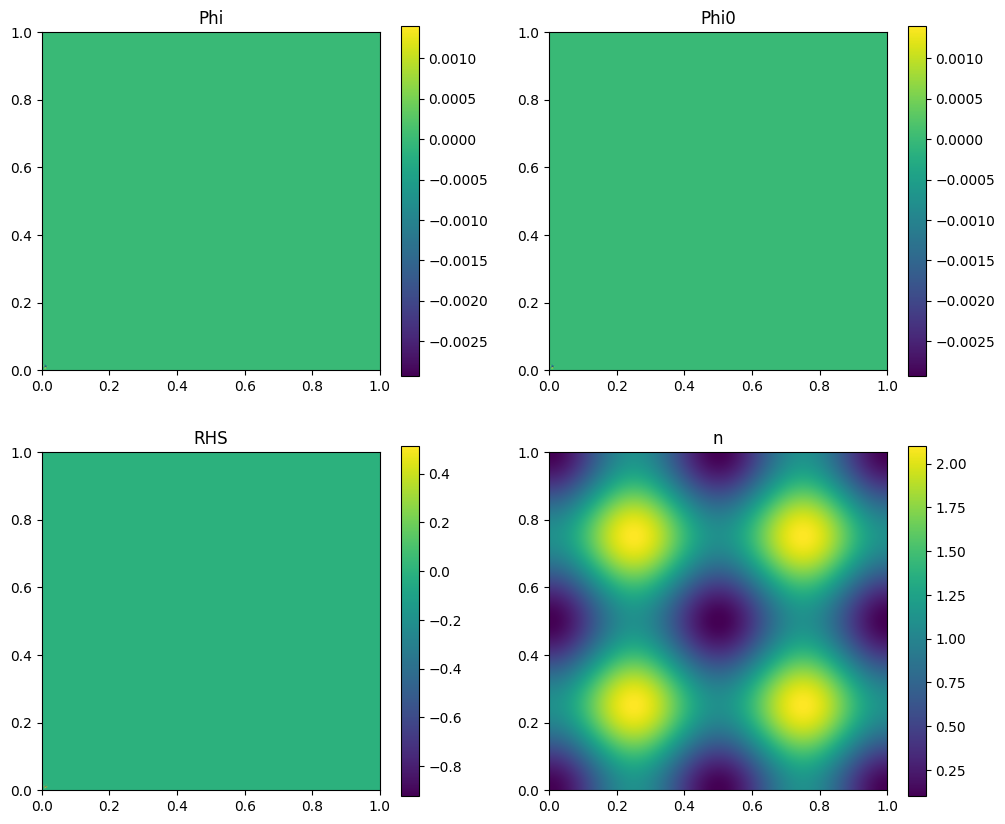

In [4]:
fig, axs = subplots(2, 2, figsize=(12, 10))
im0 = axs[0, 0].imshow(phi, origin='lower', extent=(0, 1, 0, 1))
axs[0, 0].set_title("Phi")
colorbar(im0, ax=axs[0, 0])
im1 = axs[0, 1].imshow(phi0, origin='lower', extent=(0, 1, 0, 1))
axs[0, 1].set_title("Phi0")
colorbar(im1, ax=axs[0, 1])
im2 = axs[1, 0].imshow(rhs, origin='lower', extent=(0, 1, 0, 1))
axs[1, 0].set_title("RHS")
colorbar(im2, ax=axs[1, 0])
im3 = axs[1, 1].imshow(n, origin='lower', extent=(0, 1, 0, 1))
axs[1, 1].set_title("n")
colorbar(im3, ax=axs[1, 1])

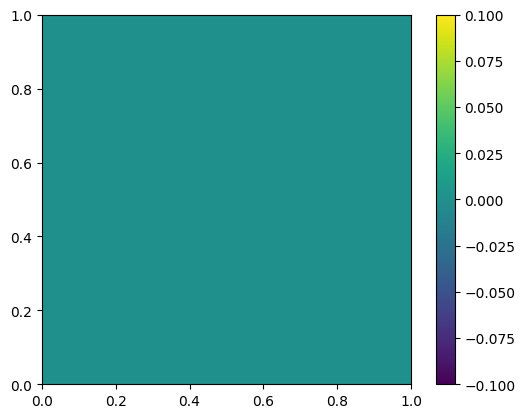

In [5]:
phi = phi - mean(phi)
phi0 = phi0 - mean(phi0)

imshow((phi-phi0), origin='lower', extent=(0, 1, 0, 1))
colorbar()